# Regresion Lineal Simple - Precio de viviendas

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Regresion Lineal Simple

---

### Objetivo

Predecir el precio de viviendas usando **una sola variable** (metros cuadrados) con regresion lineal simple. El objetivo no es solo obtener un modelo — es entender los **supuestos estadisticos** que validan (o invalidan) una regresion lineal y como diagnosticarlos.


### Contexto de negocio

**El cliente:** una inmobiliaria que necesita tasar viviendas rapidamente.

**El problema:** las tasaciones manuales tardan dias. La inmobiliaria quiere un modelo rapido que estime el precio a partir de la superficie, como primer filtro antes de la tasacion formal.

**La pregunta:** ¿Por cada metro cuadrado adicional, cuanto sube el precio?

## 1️. Setup: librerías y configuración visual

In [1]:
# Librerías base
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Modelado estadístico (interpretación)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# Machine Learning (predicción)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Tests estadísticos
from scipy import stats

# Configuración general
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(42)  # Reproducibilidad — siempre fijar la semilla

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis (1 por gráfico) / serie única en scatter y líneas
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto en un mismo gráfico
INK           = '#111111'
MUTED         = '#707070'

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [2]:
data = pd.read_excel("datos_regresion_casas.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 100 | Columnas: 4


,Metros_Cuadrados,Distancia_Centro_KM,Numero_Habitaciones,Precio_Miles_USD
0,112.4000,6.8000,4,305.8000
1,96.5000,4.1000,4,268.8000
2,116.2000,2.7000,4,330.4000
3,138.1000,5.7000,6,368.6000
4,94.1000,14.2000,4,229.6000


## 3. EDA

In [3]:
# Estadísticas descriptivas

data.describe().round(2)

,Metros_Cuadrados,Distancia_Centro_KM,Numero_Habitaciones,Precio_Miles_USD
count,100.0000,100.0000,100.0000,100.0000
mean,97.4600,7.8100,3.4500,263.5500
std,22.5600,4.0400,1.0700,57.1400
min,40.0000,1.1000,1.0000,115.1000
25%,85.0000,4.4000,3.0000,230.5800
50%,96.8000,8.1000,3.0000,266.0000
75%,110.1500,10.7200,4.0000,300.6000
max,146.3000,14.8000,6.0000,381.4000


In [4]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})

info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
Metros_Cuadrados,float64,0,0.0000,94
Distancia_Centro_KM,float64,0,0.0000,74
Numero_Habitaciones,int64,0,0.0000,6
Precio_Miles_USD,float64,0,0.0000,99


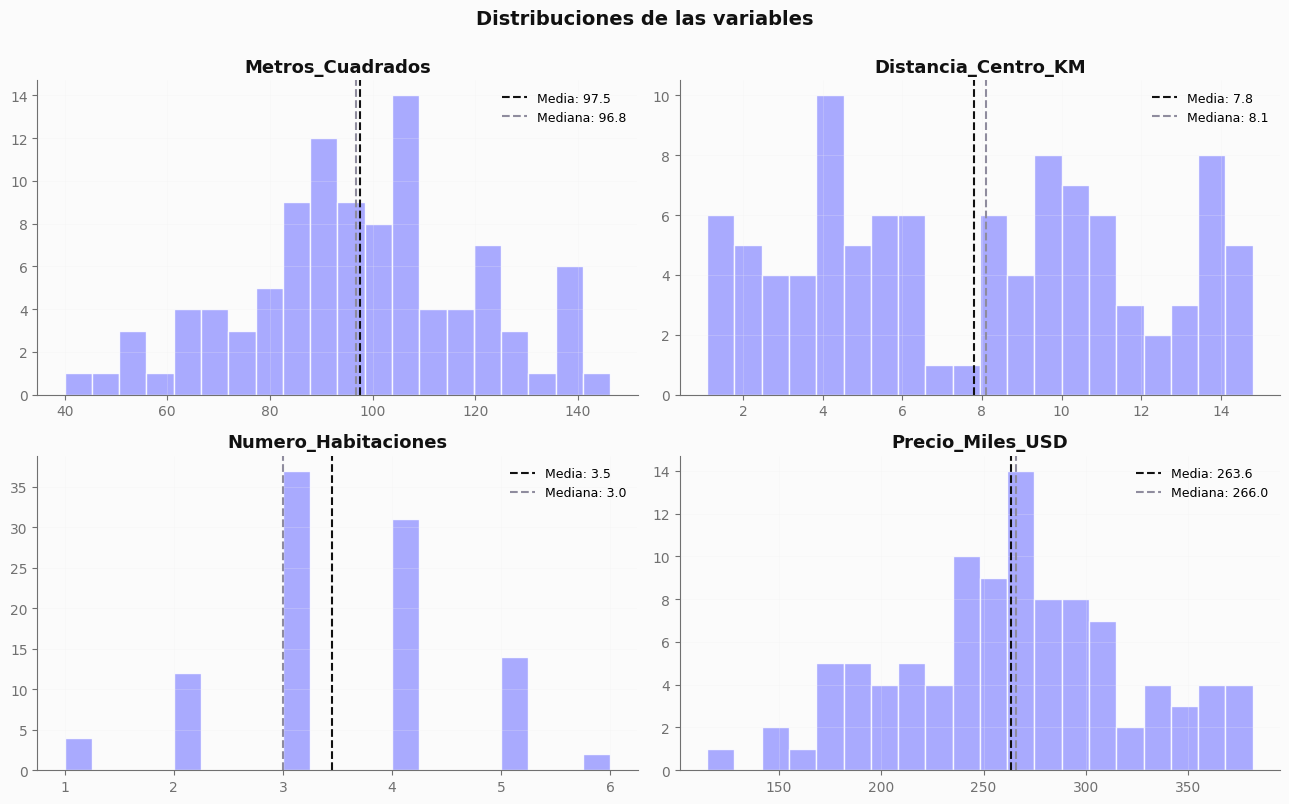

In [5]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ['Metros_Cuadrados', 'Distancia_Centro_KM', 'Numero_Habitaciones', 'Precio_Miles_USD']
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE_LIGHT, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=INK, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=NEUTRAL_LINE, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

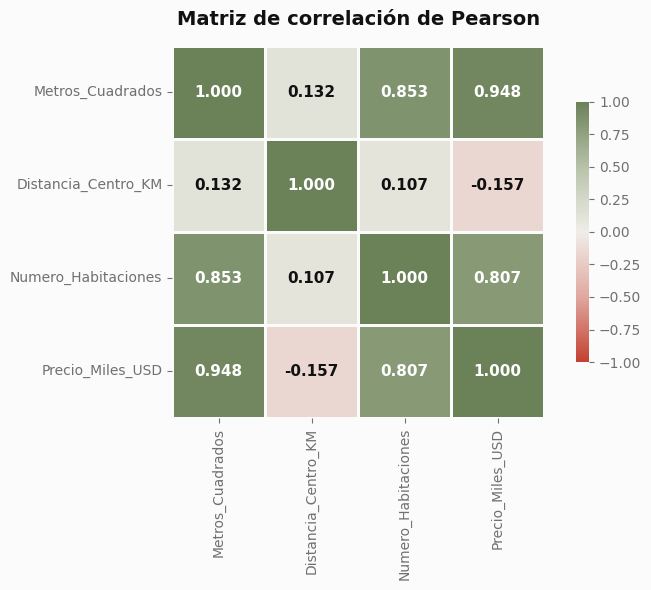

In [6]:
# Matriz de correlación
corr = data.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, fmt='.3f',
    cmap=DIVERGING_CMAP,
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=2, linecolor=BACKGROUND,
    cbar_kws={'shrink': 0.7},
    annot_kws={'size': 11, 'weight': 'bold'}
)
color_annotations(ax, corr.values, threshold=0.8)
ax.set_title('Matriz de correlación de Pearson', fontsize=14, fontweight='bold', color=INK, pad=15)
plt.tight_layout()
plt.show()

#### Columna del target (Precio)
- `Metros_cuadrados`: ~0.948 → correlación muy fuerte y positiva
- `Distancia_Centro_KM` ~-0.157 → correlación negativa moderada
- `Numero_Habitaciones` ~0.807 → correlación moderada

#### Entre variables predictoras 
`Metros_Cuadrados` ↔ `Numero_Habitaciones` ~0.853 → Estas dos variables están midiendo prácticamente. ¿multicolinealidad?


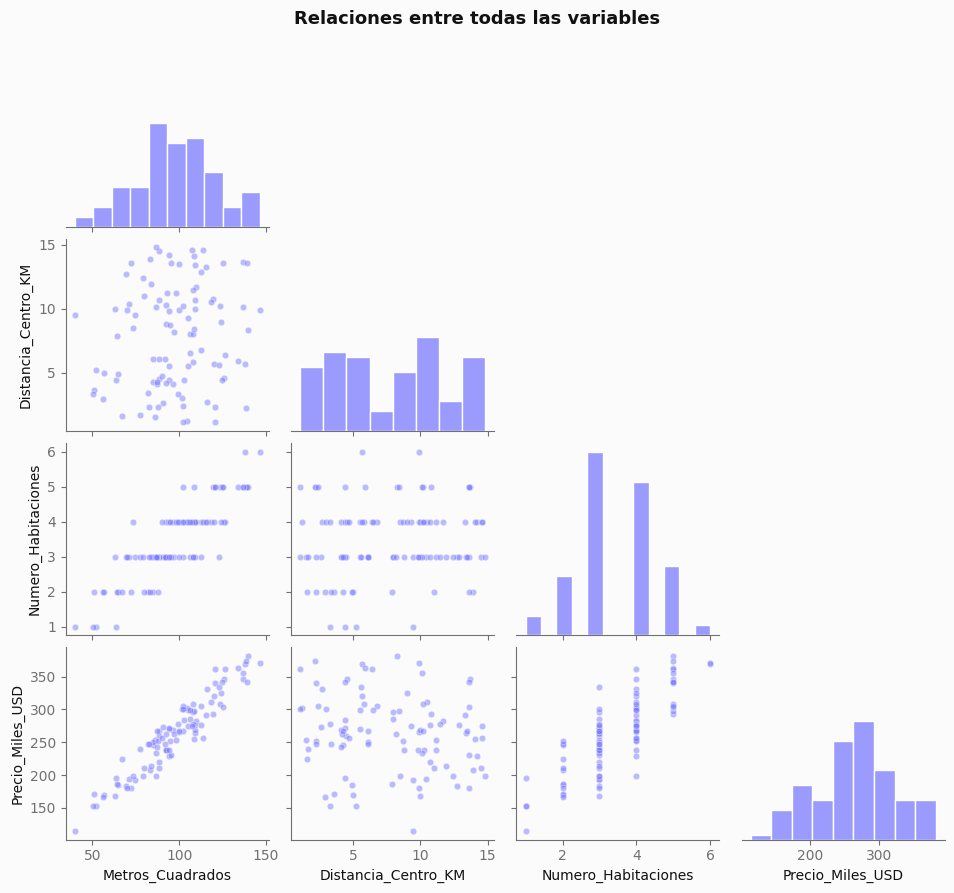

In [7]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data, height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

Para regresion lineal simple, la pregunta clave es: cual de las variables numericas tiene la **correlacion mas fuerte** con el precio?

In [8]:
corr = data.corr()["Precio_Miles_USD"].drop("Precio_Miles_USD").sort_values(ascending=False)
print("Correlaciones con el precio:")
print(corr.round(4).to_string())
print()
print(f"Variable con mayor correlacion: {corr.index[0]} (r={corr.iloc[0]:.4f})")

Correlaciones con el precio:
Metros_Cuadrados       0.9482
Numero_Habitaciones    0.8074
Distancia_Centro_KM   -0.1569

Variable con mayor correlacion: Metros_Cuadrados (r=0.9482)


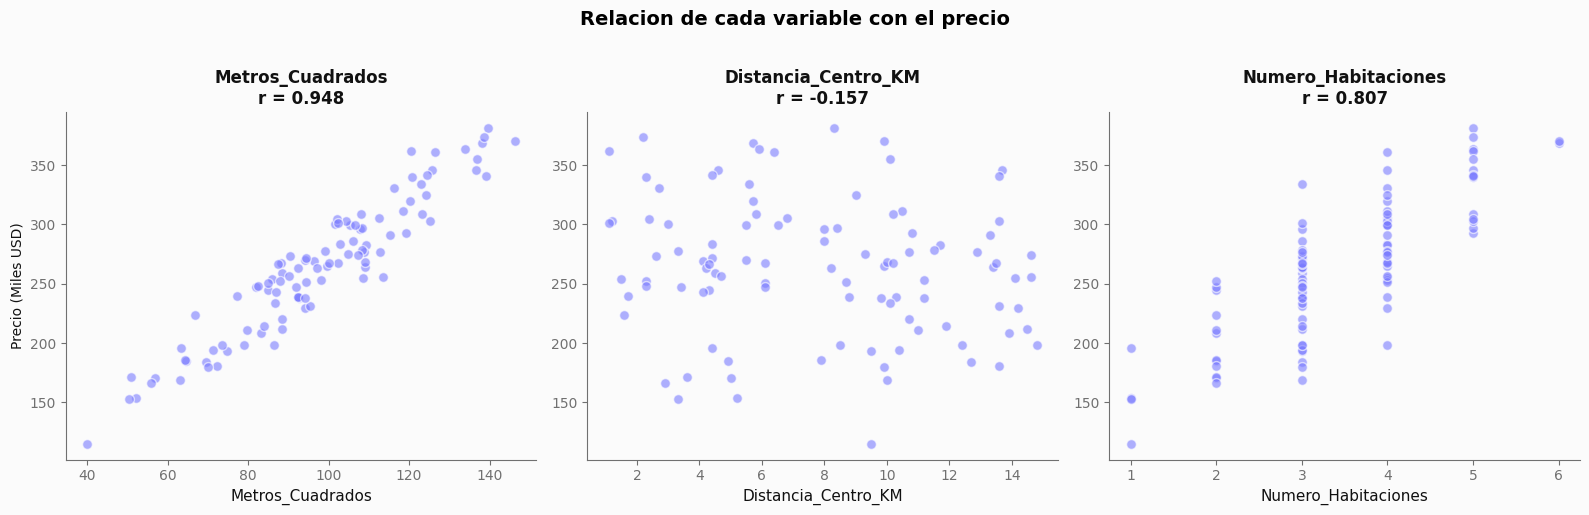

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(["Metros_Cuadrados", "Distancia_Centro_KM", "Numero_Habitaciones"]):
    axes[i].scatter(data[col], data["Precio_Miles_USD"], color=PURPLE, alpha=0.6, edgecolors="white", s=50)
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel("Precio (Miles USD)" if i == 0 else "")
    r = data[col].corr(data["Precio_Miles_USD"])
    axes[i].set_title(f"{col}\nr = {r:.3f}", fontsize=12, fontweight="bold")

plt.suptitle("Relacion de cada variable con el precio", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


- `Metros_Cuadrados` muestra la relacion lineal mas clara y fuerte con el precio. Es nuestra variable predictora para la regresion simple.

## 4. Selección del modelo

### Modelo 1 - Regresión Lineal Simple

#### Preparacion de datos

In [10]:
# 1. Definimos X (predictoras) e y (target)
X1 = data[['Metros_Cuadrados']]
y  = data['Precio_Miles_USD']

# 2. PASO IMPRESCINDIBLE: añadir la constante (el intercepto)
#    statsmodels NO lo añade automáticamente. Si te lo olvidas, el modelo asume
#    que la recta pasa por el origen, lo cual casi nunca tiene sentido.
X1_const = sm.add_constant(X1)

# 3. Ajustamos el modelo (OLS = Ordinary Least Squares = Mínimos Cuadrados Ordinarios)
modelo_1 = sm.OLS(y, X1_const).fit()

# 4. Imprimimos el resumen completo
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:       Precio_Miles_USD   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     873.9
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           1.27e-50
Time:                        11:25:24   Log-Likelihood:                -431.23
No. Observations:                 100   AIC:                             866.5
Df Residuals:                      98   BIC:                             871.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               29.4315      8.127  

- **R-squared** → 0.899 (cerca del 1) tenemos un buen modelo.
- **P>|t|** → `Metros_Cuadrados` con un p-valor < 0.05. La variable importa 

In [11]:
# Extraemos los valores clave del modelo
print(' RESUMEN DEL MODELO 1 (Regresión Simple)')
print('═' * 60)
print(f'  R²                : {modelo_1.rsquared:.6f}')
print(f'  R² ajustado       : {modelo_1.rsquared_adj:.6f}')
print(f'  F-statistic       : {modelo_1.fvalue:.2f}')
print(f'  Prob (F)          : {modelo_1.f_pvalue:.4e}')
print(f'  AIC               : {modelo_1.aic:.2f}')
print(f'  Nº observaciones  : {int(modelo_1.nobs)}')
print()

# Tabla de coeficientes con interpretación
coefs_1 = pd.DataFrame({
    'Coeficiente': modelo_1.params.round(4),
    'Error típico': modelo_1.bse.round(4),
    't': modelo_1.tvalues.round(4),
    'p-valor': modelo_1.pvalues.apply(lambda x: f'{x:.4e}'),
    'Significativo': modelo_1.pvalues.apply(lambda x: 'Sí' if x < 0.05 else 'No')
})
print('COEFICIENTES:')
print(coefs_1)

# Ecuación final del modelo
b0 = modelo_1.params['const']
b1 = modelo_1.params['Metros_Cuadrados']
print(f'\n ECUACIÓN: Precio = {b0:.2f} + {b1:.2f} × Metros_Cuadrados')

 RESUMEN DEL MODELO 1 (Regresión Simple)
════════════════════════════════════════════════════════════
  R²                : 0.899166
  R² ajustado       : 0.898137
  F-statistic       : 873.89
  Prob (F)          : 1.2723e-50
  AIC               : 866.46
  Nº observaciones  : 100

COEFICIENTES:
                  Coeficiente  Error típico       t     p-valor Significativo
const                 29.4315        8.1270  3.6215  4.6609e-04            Sí
Metros_Cuadrados       2.4022        0.0813 29.5617  1.2723e-50            Sí

 ECUACIÓN: Precio = 29.43 + 2.40 × Metros_Cuadrados


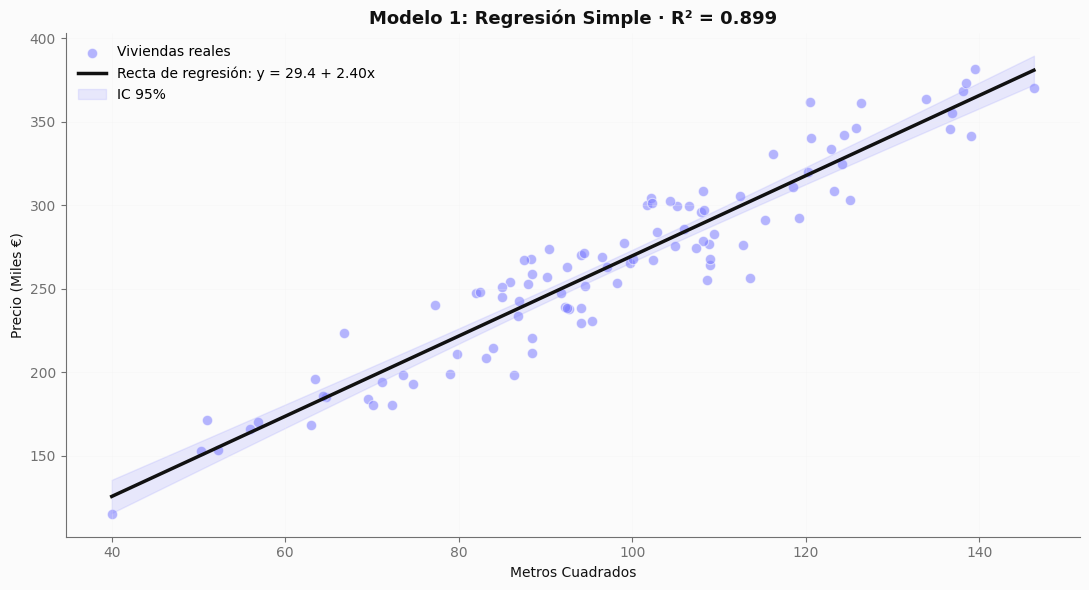

In [12]:
# Visualización del modelo
fig, ax = plt.subplots(figsize=(11, 6))

# Puntos reales
ax.scatter(data['Metros_Cuadrados'], data['Precio_Miles_USD'],
           color=PURPLE, alpha=0.55, s=55, edgecolor='white', linewidth=0.8, label='Viviendas reales')

# Línea de regresión
x_line = np.linspace(data['Metros_Cuadrados'].min(), data['Metros_Cuadrados'].max(), 100)
y_line = b0 + b1 * x_line
ax.plot(x_line, y_line, color=INK, linewidth=2.5, label=f'Recta de regresión: y = {b0:.1f} + {b1:.2f}x')

# Banda de confianza al 95%
predictions = modelo_1.get_prediction(sm.add_constant(pd.DataFrame({'Metros_Cuadrados': x_line})))
ci = predictions.conf_int(alpha=0.05)
ax.fill_between(x_line, ci[:, 0], ci[:, 1], color=PURPLE, alpha=0.15, label='IC 95%')

ax.set_xlabel('Metros Cuadrados')
ax.set_ylabel('Precio (Miles €)')
ax.set_title(f'Modelo 1: Regresión Simple · R² = {modelo_1.rsquared:.3f}', fontsize=13, fontweight='bold', color=INK)
ax.legend(loc='upper left', frameon=False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusión:

- Con solo los metros cuadrados ya podemos explicar el 89% del precio. Cada m² extra añade ~2,4 mil USD al precio. Pero hay un 11% sin explicar que probablemente viene de la ubicación; vamos a meterla y vemos."

### Modelo 2 - Regresión Lineal Múltiple

- Añadimos la distancia al centro

- **Hipótesis de negocio:** una vivienda más alejada del centro será más barata, aunque tenga el mismo tamaño.

In [13]:
# Modelo 2: Regresión Múltiple con 2 variables
X2 = data[['Metros_Cuadrados', 'Distancia_Centro_KM']]
X2_const = sm.add_constant(X2)
modelo_2 = sm.OLS(y, X2_const).fit()

print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:       Precio_Miles_USD   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     2412.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           1.96e-83
Time:                        11:25:24   Log-Likelihood:                -349.61
No. Observations:                 100   AIC:                             705.2
Df Residuals:                      97   BIC:                             713.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  51.8075    

In [14]:
# Resumen comparativo
print('RESUMEN DEL MODELO 2 (Regresión Múltiple — 2 variables)')
print('═' * 60)
print(f'  R²                : {modelo_2.rsquared:.6f}   ← antes: {modelo_1.rsquared:.6f}')
print(f'  R² ajustado       : {modelo_2.rsquared_adj:.6f}   ← antes: {modelo_1.rsquared_adj:.6f}')
print(f'  AIC               : {modelo_2.aic:.2f}        ← antes: {modelo_1.aic:.2f}')
print(f'  Error típico (s)  : {np.sqrt(modelo_2.mse_resid):.4f}   ← antes: {np.sqrt(modelo_1.mse_resid):.4f}')
print()

coefs_2 = pd.DataFrame({
    'Coeficiente': modelo_2.params.round(4),
    'Error típico': modelo_2.bse.round(4),
    't': modelo_2.tvalues.round(4),
    'p-valor': modelo_2.pvalues.apply(lambda x: f'{x:.4e}'),
    'Significativo': modelo_2.pvalues.apply(lambda x: 'Sí' if x < 0.05 else 'No')
})
print('COEFICIENTES:')
print(coefs_2)

RESUMEN DEL MODELO 2 (Regresión Múltiple — 2 variables)
════════════════════════════════════════════════════════════
  R²                : 0.980289   ← antes: 0.899166
  R² ajustado       : 0.979883   ← antes: 0.898137
  AIC               : 705.23        ← antes: 866.46
  Error típico (s)  : 8.1046   ← antes: 18.2373

COEFICIENTES:
                     Coeficiente  Error típico        t     p-valor  \
const                    51.8075        3.7813  13.7011  2.0640e-24   
Metros_Cuadrados          2.4985        0.0364  68.5788  5.3677e-84   
Distancia_Centro_KM      -4.0675        0.2036 -19.9807  3.7286e-36   

                    Significativo  
const                          Sí  
Metros_Cuadrados               Sí  
Distancia_Centro_KM            Sí  


**Lectura de coeficientes para negocio:**
- Cada m² adicional sube el precio en ~2,5 mil €, **manteniendo la distancia al centro constante**.
- Cada km extra de distancia al centro baja el precio en ~4 mil €, **manteniendo los m² constantes**.

#### Modelo 3 — Añadimos `Numero_Habitaciones`


In [15]:
# === Modelo 3: añadimos Numero_Habitaciones ===
X3 = data[['Metros_Cuadrados', 'Distancia_Centro_KM', 'Numero_Habitaciones']]
X3_const = sm.add_constant(X3)
modelo_3 = sm.OLS(y, X3_const).fit()

print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:       Precio_Miles_USD   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     1594.
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           1.01e-81
Time:                        11:25:24   Log-Likelihood:                -349.54
No. Observations:                 100   AIC:                             707.1
Df Residuals:                      96   BIC:                             717.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  51.5424    

In [16]:
# === Análisis del Modelo 3 ===
print('RESUMEN DEL MODELO 3 (Regresión Múltiple — 3 variables)')
print('═' * 60)
print(f'  R²                : {modelo_3.rsquared:.6f}   ← Modelo 2: {modelo_2.rsquared:.6f}')
print(f'  R² ajustado       : {modelo_3.rsquared_adj:.6f}   ← Modelo 2: {modelo_2.rsquared_adj:.6f}')
print(f'  AIC               : {modelo_3.aic:.2f}        ← Modelo 2: {modelo_2.aic:.2f}')
print()

coefs_3 = pd.DataFrame({
    'Coeficiente': modelo_3.params.round(4),
    'Error típico': modelo_3.bse.round(4),
    't': modelo_3.tvalues.round(4),
    'p-valor': modelo_3.pvalues.apply(lambda x: f'{x:.4e}'),
    'Significativo': modelo_3.pvalues.apply(lambda x: 'Sí' if x < 0.05 else 'No')
})
print('COEFICIENTES:')
print(coefs_3)

RESUMEN DEL MODELO 3 (Regresión Múltiple — 3 variables)
════════════════════════════════════════════════════════════
  R²                : 0.980319   ← Modelo 2: 0.980289
  R² ajustado       : 0.979704   ← Modelo 2: 0.979883
  AIC               : 707.08        ← Modelo 2: 705.23

COEFICIENTES:
                     Coeficiente  Error típico        t     p-valor  \
const                    51.5424        3.8614  13.3483  1.3319e-23   
Metros_Cuadrados          2.5211        0.0697  36.1812  9.6414e-58   
Distancia_Centro_KM      -4.0683        0.2045 -19.8953  7.9049e-36   
Numero_Habitaciones      -0.5590        1.4683  -0.3807  7.0426e-01   

                    Significativo  
const                          Sí  
Metros_Cuadrados               Sí  
Distancia_Centro_KM            Sí  
Numero_Habitaciones            No  


- **R² ajustado ha BAJADO** → si baja al añadir una variable, es que sobra. 
- **El p-valor de `Numero_Habitaciones` es > 0,05** → No significativa.


#### Comparamos los 3 modelos

In [17]:
# Tabla comparativa
comparativa = pd.DataFrame({
    'Modelo 1 (1 var)':       [modelo_1.rsquared, modelo_1.rsquared_adj, modelo_1.aic, modelo_1.bic, np.sqrt(modelo_1.mse_resid), modelo_1.df_model],
    'Modelo 2 (2 var)':       [modelo_2.rsquared, modelo_2.rsquared_adj, modelo_2.aic, modelo_2.bic, np.sqrt(modelo_2.mse_resid), modelo_2.df_model],
    'Modelo 3 (3 var)':       [modelo_3.rsquared, modelo_3.rsquared_adj, modelo_3.aic, modelo_3.bic, np.sqrt(modelo_3.mse_resid), modelo_3.df_model],
}, index=['R²', 'R² ajustado', 'AIC', 'BIC', 'Error típico (s)', 'Nº variables']).round(4)

comparativa

,Modelo 1 (1 var),Modelo 2 (2 var),Modelo 3 (3 var)
R²,0.8992,0.9803,0.9803
R² ajustado,0.8981,0.9799,0.9797
AIC,866.4615,705.2293,707.0785
BIC,871.6719,713.0448,717.4991
Error típico (s),18.2373,8.1046,8.1406
Nº variables,1.0000,2.0000,3.0000


### Comprobamos si existe multicolinealidad

In [18]:
# Calculamos VIF para el Modelo 3 (donde tenemos sospecha)
def calcular_vif(X):
    """Calcula el VIF para cada predictor de X (sin constante)."""
    X_c = sm.add_constant(X)
    vif = pd.DataFrame({
        'Variable': X_c.columns,
        'VIF': [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
    })
    vif = vif[vif['Variable'] != 'const'].reset_index(drop=True)
    vif['Diagnóstico'] = vif['VIF'].apply(
        lambda v: 'OK' if v < 5 else ('Vigilar' if v < 10 else 'Grave')
    )
    return vif

print('VIF del MODELO 3 (3 variables):')
print(calcular_vif(X3).to_string(index=False))

print('\nVIF del MODELO 2 (2 variables):')
print(calcular_vif(X2).to_string(index=False))

VIF del MODELO 3 (3 variables):
           Variable    VIF Diagnóstico
   Metros_Cuadrados 3.6902          OK
Distancia_Centro_KM 1.0179          OK
Numero_Habitaciones 3.6678          OK

VIF del MODELO 2 (2 variables):
           Variable    VIF Diagnóstico
   Metros_Cuadrados 1.0178          OK
Distancia_Centro_KM 1.0178          OK


### GANADOR: MODELO 2
- Mejor R² ajustado
- Menor AIC
- Todas las variables significativas (p < 0.05)
- Más simple que el Modelo 3 sin perder capacidad explicativa

### Diagnóstico de residuos ¿es válido nuestro modelo?

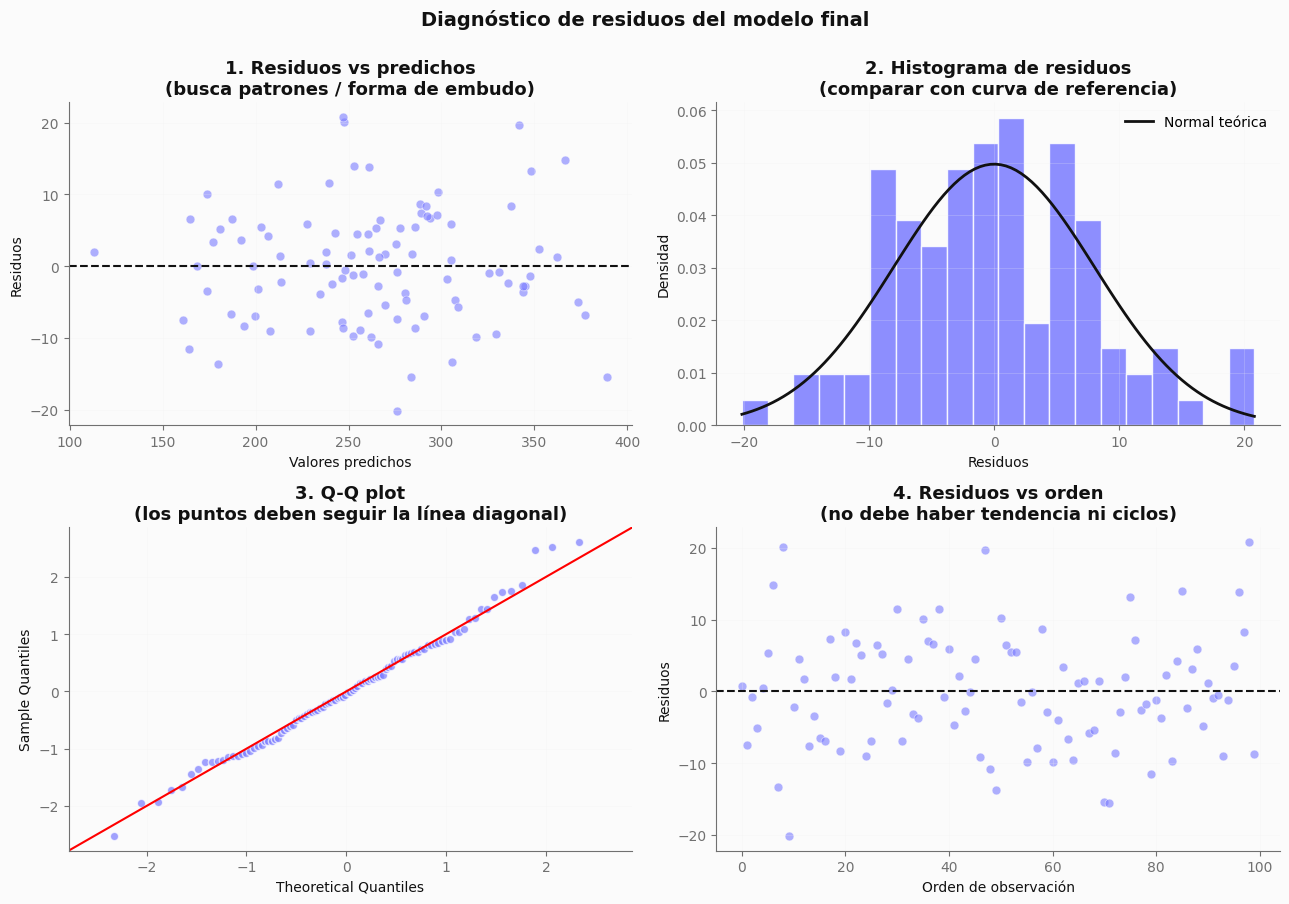

In [19]:
modelo_final = modelo_2
residuos = modelo_final.resid
predichos = modelo_final.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Diagnóstico de residuos del modelo final', fontsize=14, fontweight='bold', color=INK, y=1.00)

# 1. Residuos vs valores predichos (linealidad + homocedasticidad)
axes[0, 0].scatter(predichos, residuos, color=PURPLE, alpha=0.6, s=40, edgecolor='white', linewidth=0.5)
axes[0, 0].axhline(0, color=INK, linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Valores predichos')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('1. Residuos vs predichos\n(busca patrones / forma de embudo)', color=INK)
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma de residuos (normalidad)
axes[0, 1].hist(residuos, bins=20, color=PURPLE, edgecolor='white', alpha=0.85, density=True)
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
                color=INK, linewidth=2, label='Normal teórica')
axes[0, 1].set_xlabel('Residuos')
axes[0, 1].set_ylabel('Densidad')
axes[0, 1].set_title('2. Histograma de residuos\n(comparar con curva de referencia)', color=INK)
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (normalidad)
sm.qqplot(residuos, line='45', fit=True, ax=axes[1, 0],
          markerfacecolor=PURPLE, markeredgecolor='white', alpha=0.7, markersize=6)
axes[1, 0].set_title('3. Q-Q plot\n(los puntos deben seguir la línea diagonal)', color=INK)
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuos vs orden (independencia)
axes[1, 1].scatter(range(len(residuos)), residuos, color=PURPLE, alpha=0.6, s=40, edgecolor='white', linewidth=0.5)
axes[1, 1].axhline(0, color=INK, linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel('Orden de observación')
axes[1, 1].set_ylabel('Residuos')
axes[1, 1].set_title('4. Residuos vs orden\n(no debe haber tendencia ni ciclos)', color=INK)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Validación con train/test split

In [20]:
X = data[['Metros_Cuadrados', 'Distancia_Centro_KM']]   # solo las 2 variables del modelo ganador
y = data['Precio_Miles_USD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 75 registros
Test:  25 registros


In [21]:
# Entrenamos con sklearn

model = LinearRegression()
model.fit(X_train, y_train)

# Predicciones

b0 = model.intercept_
b1 = model.coef_[0]

print("Ecuacion del modelo:")
print(f"  Precio = {b0:.2f} + {b1:.2f} * Metros_Cuadrados")
print()
print("Interpretacion:")
print(f"  - Intercepto: {b0:.2f} miles USD (precio base teorico a 0 m2)")
print(f"  - Pendiente: {b1:.2f} miles USD por m2 adicional")
print(f"  - Cada metro cuadrado adicional anade ~{b1:.0f}.000 USD al precio")

Ecuacion del modelo:
  Precio = 48.91 + 2.52 * Metros_Cuadrados

Interpretacion:
  - Intercepto: 48.91 miles USD (precio base teorico a 0 m2)
  - Pendiente: 2.52 miles USD por m2 adicional
  - Cada metro cuadrado adicional anade ~3.000 USD al precio


In [22]:
# Entrenamos con sklearn
modelo_ml = LinearRegression()
modelo_ml.fit(X_train, y_train)

# Predicciones
y_pred_train = modelo_ml.predict(X_train)
y_pred_test  = modelo_ml.predict(X_test)

# Métricas
def metricas(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    print(f'{nombre}:')
    print(f'  R²    : {r2:.4f}')
    print(f'  RMSE  : {rmse:.2f}  (raíz del error cuadrático medio, en miles USD)')
    print(f'  MAE   : {mae:.2f}  (error absoluto medio, en miles USD)')
    print(f'  MAPE  : {mape:.2f}%  (error porcentual medio)')
    return r2, rmse

print('═' * 60)
r2_train, rmse_train = metricas(y_train, y_pred_train, 'TRAIN (datos vistos)')
print()
r2_test,  rmse_test  = metricas(y_test, y_pred_test, 'TEST (datos nuevos)')
print('═' * 60)

# Diagnóstico de overfitting
diff_r2 = r2_train - r2_test
print(f'\nDiferencia R²: {diff_r2:.4f}')
if abs(diff_r2) < 0.05:
    print('No hay overfitting: el modelo generaliza bien.')
elif diff_r2 > 0.05:
    print('Posible overfitting: el modelo va mejor en train que en test.')
else:
    print('Atípico: el modelo va mejor en test (poco común, revisar muestra).')

════════════════════════════════════════════════════════════
TRAIN (datos vistos):
  R²    : 0.9798
  RMSE  : 8.53  (raíz del error cuadrático medio, en miles USD)
  MAE   : 6.94  (error absoluto medio, en miles USD)
  MAPE  : 2.75%  (error porcentual medio)

TEST (datos nuevos):
  R²    : 0.9819
  RMSE  : 6.19  (raíz del error cuadrático medio, en miles USD)
  MAE   : 4.70  (error absoluto medio, en miles USD)
  MAPE  : 1.79%  (error porcentual medio)
════════════════════════════════════════════════════════════

Diferencia R²: -0.0021
No hay overfitting: el modelo generaliza bien.


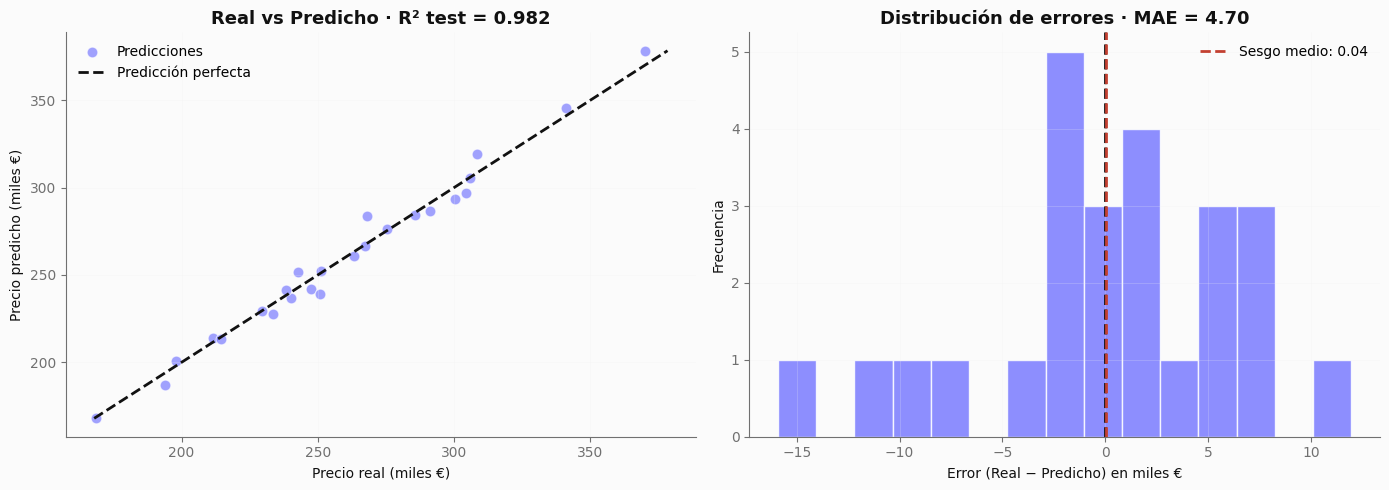

In [23]:
# Visualizamos la calidad de predicción
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs predicho
axes[0].scatter(y_test, y_pred_test, color=PURPLE, alpha=0.7, s=60, edgecolor='white', linewidth=0.8, label='Predicciones')
min_val, max_val = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color=INK, linestyle='--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio real (miles €)')
axes[0].set_ylabel('Precio predicho (miles €)')
axes[0].set_title(f'Real vs Predicho · R² test = {r2_test:.3f}', color=INK)
axes[0].legend(frameon=False)
axes[0].grid(True, alpha=0.3)

# Errores de predicción
errores_test = y_test - y_pred_test
axes[1].hist(errores_test, bins=15, color=PURPLE, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color=INK, linestyle='--', linewidth=2)
axes[1].axvline(errores_test.mean(), color=NEGATIVE, linestyle='--', linewidth=2, label=f'Sesgo medio: {errores_test.mean():.2f}')
axes[1].set_xlabel('Error (Real − Predicho) en miles €')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de errores · MAE = {mean_absolute_error(y_test, y_pred_test):.2f}', color=INK)
axes[1].legend(frameon=False)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Predicción del precio antes posibles caso de tasación


def predecir_precio(metros_cuadrados, distancia_centro_km, modelo=modelo_ml, incertidumbre=True):
    """
    Predice el precio de una vivienda en miles de euros.
    
    Parámetros
    ----------
    metros_cuadrados : float
        Superficie en m².
    distancia_centro_km : float
        Distancia al centro en km.
    modelo : sklearn.linear_model.LinearRegression
        Modelo entrenado.
    incertidumbre : bool
        Si True, devuelve también un intervalo aproximado ±1.96·RMSE.
    
    Devuelve
    -------
    dict con la predicción y, si se pide, el intervalo de confianza al 95%.
    """
    X_nuevo = pd.DataFrame({
        'Metros_Cuadrados': [metros_cuadrados],
        'Distancia_Centro_KM': [distancia_centro_km]
    })
    pred = modelo.predict(X_nuevo)[0]
    resultado = {'precio_predicho_miles_eur': round(pred, 2)}
    if incertidumbre:
        margen = 1.96 * rmse_test
        resultado['intervalo_95'] = (round(pred - margen, 2), round(pred + margen, 2))
    return resultado

# === Ejemplos de uso ===
print('EJEMPLOS DE PREDICCIÓN')
print('─' * 60)

casos = [
    {'metros': 80,  'distancia': 2,  'descripcion': 'Piso pequeño céntrico'},
    {'metros': 120, 'distancia': 8,  'descripcion': 'Piso medio periferia'},
    {'metros': 180, 'distancia': 1,  'descripcion': 'Piso grande céntrico (lujo)'},
]

for caso in casos:
    pred = predecir_precio(caso['metros'], caso['distancia'])
    print(f"\n{caso['descripcion']}: {caso['metros']} m², {caso['distancia']} km del centro")
    print(f"  Precio estimado : {pred['precio_predicho_miles_eur']:,.2f} mil €")
    print(f"  Intervalo 95%   : {pred['intervalo_95'][0]:,.2f} – {pred['intervalo_95'][1]:,.2f} mil €")

EJEMPLOS DE PREDICCIÓN
────────────────────────────────────────────────────────────

Piso pequeño céntrico: 80 m², 2 km del centro
  Precio estimado : 242.65 mil €
  Intervalo 95%   : 230.51 – 254.78 mil €

Piso medio periferia: 120 m², 8 km del centro
  Precio estimado : 319.61 mil €
  Intervalo 95%   : 307.47 – 331.74 mil €

Piso grande céntrico (lujo): 180 m², 1 km del centro
  Precio estimado : 498.75 mil €
  Intervalo 95%   : 486.62 – 510.88 mil €


## 6. Insights de negocio y recomendaciones


El siguiente modelo precide el precio de una vivienda con un **98% de fiabilidad** usando solo dos variables: los **metros cuadrados** y la **distancia al centro**.

**Las reglas que ha aprendido el modelo son estas:**
- Cada **m² adicional añade ~2.500 €** al precio (manteniendo la ubicación fija).
- Cada **km de distancia al centro resta ~4.000 €** al precio (manteniendo el tamaño fijo).

**¿Y el número de habitaciones?** Lo probamos y resultó que **no aporta información nueva**: una vez sabemos los metros cuadrados, las habitaciones son consecuencia de eso. El modelo es más simple y más preciso sin esa variable.

**Precisión real del modelo:** cuando predice viviendas nuevas, se equivoca de media en ±5.000 € — muy por debajo del margen comercial típico de tasación.